Testing trained WideResnet28 models.


Initializing environment

In [16]:
!pip install git+https://github.com/KarolKutyla/awp_tf_tests.git

from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf

from awp_tf_tests.datasets.v2 import cifar_10
from awp_tf.attacks.v2.pgd import PGDAttack, PGDParams

from awp_tf_tests.visualisation.draw_attacks_v2 import AdversarialPlots
from awp_tf_tests.models.implementations.wide_resnet_28 import KaimingNormal

tf.config.run_functions_eagerly(False)

train_ds, test_ds = cifar_10.load_cifar_dataset()
labels = cifar_10.load_cifar_labels()
steps_per_epoch = train_ds.cardinality()

attack_params = PGDParams(perturbation_bound=128/255, pgd_step=20, pgd_step_size=15/255, norm="l2")


def get_checkpoint_path(model_name):
    return f"/content/drive/MyDrive/checkpoints/{model_name}/epoch_200.keras"


def make_adv_test_set(ds, attack, batch_size=128):

    adv_x = []
    adv_y = []

    for i, (x, y) in enumerate(iter(ds)):
      print(f"{i}/{ds.cardinality()}")
      x_adv = attack.generate(x, y)
      adv_x.append(x_adv)
      adv_y.append(y)

    x_adv = tf.concat(adv_x, axis=0)
    y_adv = tf.concat(adv_y, axis=0)

    return x_adv, y_adv

  Cloning https://github.com/KarolKutyla/awp_tf_tests.git to /tmp/pip-req-build-ztapxn6k
  Running command git clone --filter=blob:none --quiet https://github.com/KarolKutyla/awp_tf_tests.git /tmp/pip-req-build-ztapxn6k
  Resolved https://github.com/KarolKutyla/awp_tf_tests.git to commit 3dbf0fe50760ff9841afd31cd4c6ea73a3ace8cd
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/KarolKutyla/awp_tf.git to /tmp/pip-install-mus15kt4/awp-tf_9727e952aa9f46bbbfe5fb0197e3040c
  Running command git clone --filter=blob:none --quiet https://github.com/KarolKutyla/awp_tf.git /tmp/pip-install-mus15kt4/awp-tf_9727e952aa9f46bbbfe5fb0197e3040c
  Resolved https://github.com/KarolKutyla/awp_tf.git to commit 035ecafb9fface0be31cd2ffe3585fda1e665512
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Drive alread

Visualizing adversarial examples on single batch from train dataset and evaluating trained model on test dataset

0/79
1/79
2/79
3/79
4/79
5/79
6/79
7/79
8/79
9/79
10/79
11/79
12/79
13/79
14/79
15/79
16/79
17/79
18/79
19/79
20/79
21/79
22/79
23/79
24/79
25/79
26/79
27/79
28/79
29/79
30/79
31/79
32/79
33/79
34/79
35/79
36/79
37/79
38/79
39/79
40/79
41/79
42/79
43/79
44/79
45/79
46/79
47/79
48/79
49/79
50/79
51/79
52/79
53/79
54/79
55/79
56/79
57/79
58/79
59/79
60/79
61/79
62/79
63/79
64/79
65/79
66/79
67/79
68/79
69/79
70/79
71/79
72/79
73/79
74/79
75/79
76/79
77/79
78/79
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - accuracy: 0.9481 - loss: 0.2497
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.0057 - loss: 33.1371


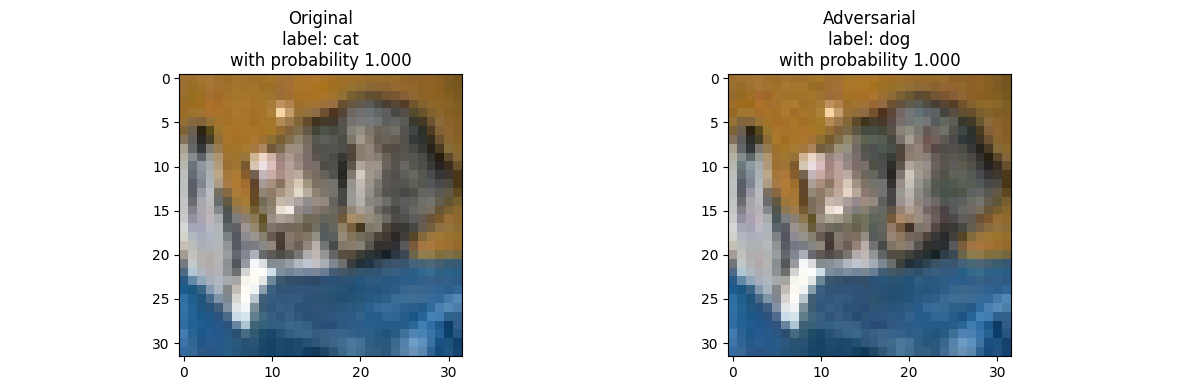

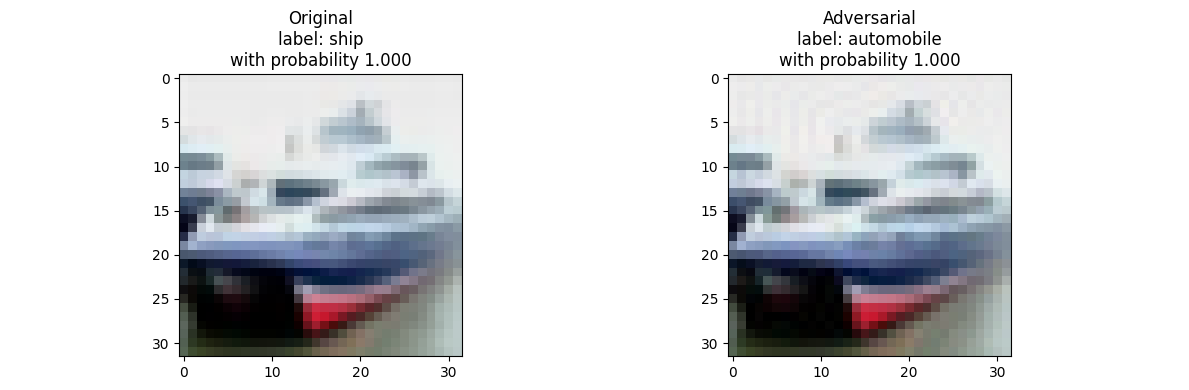

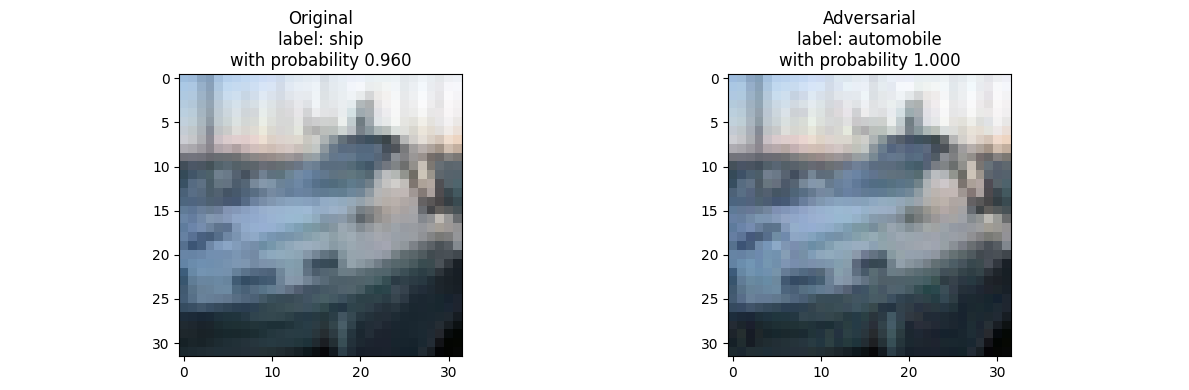

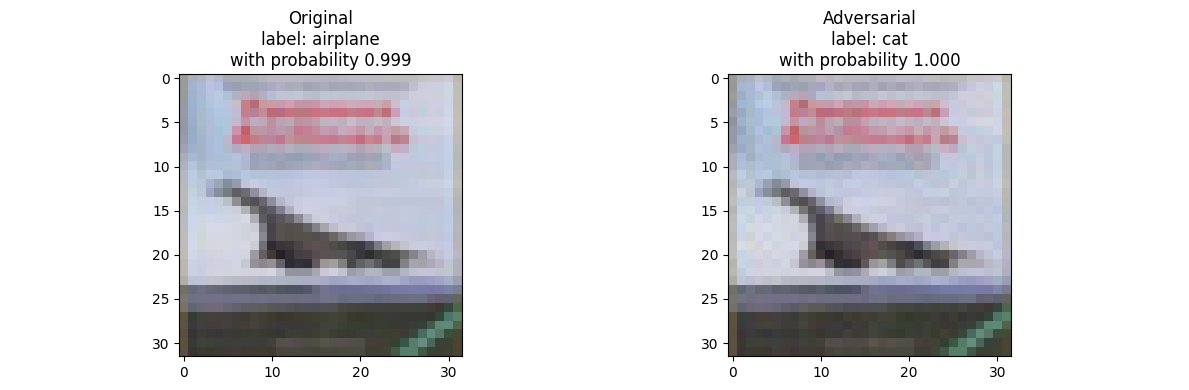

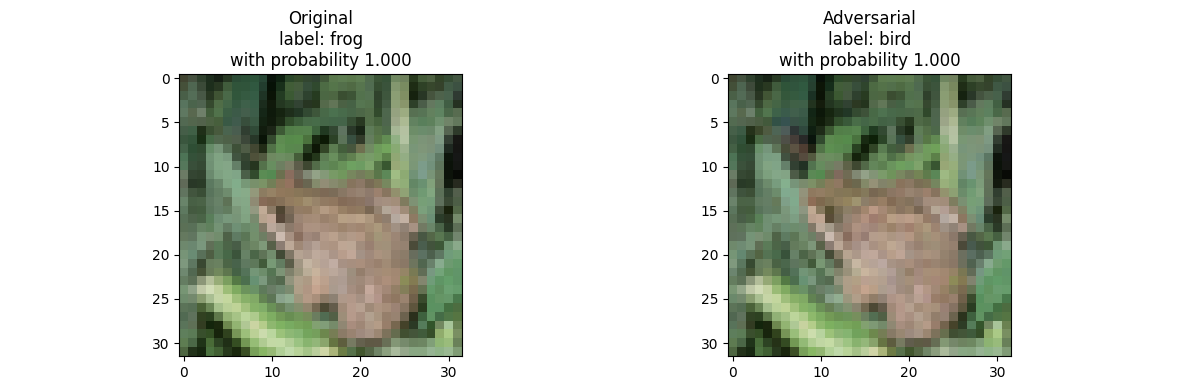

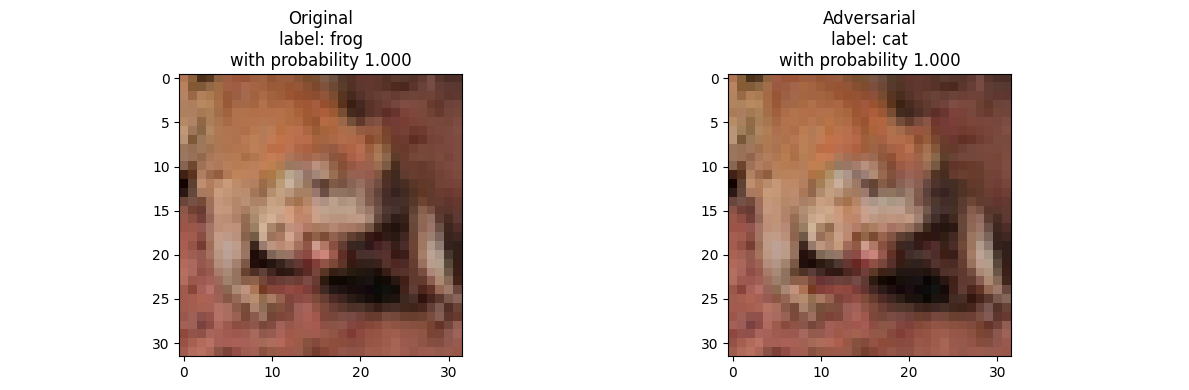

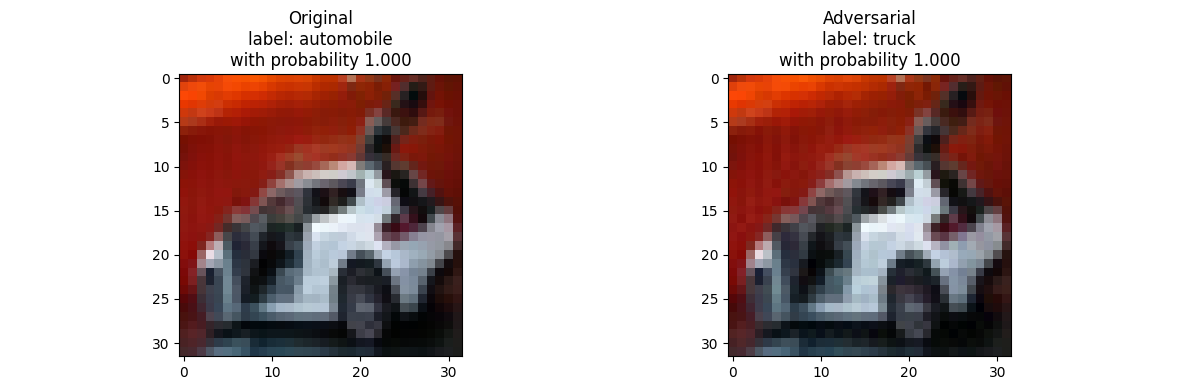

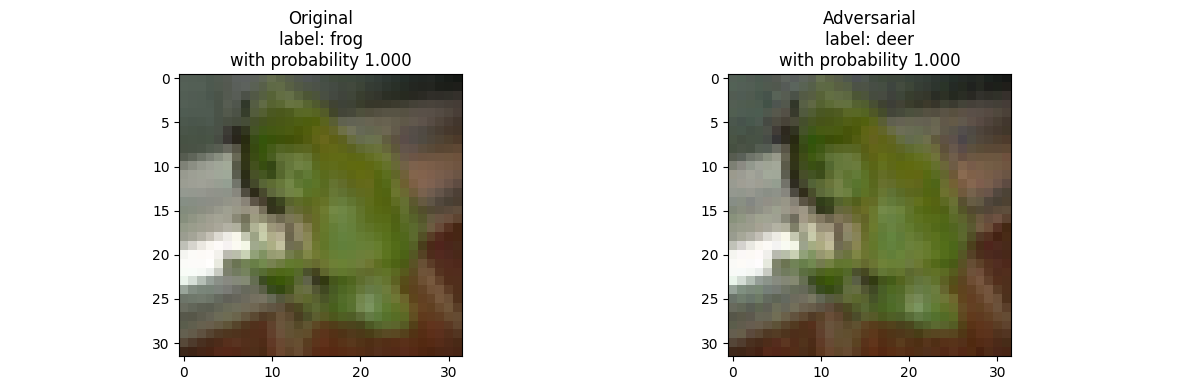

In [11]:
model = tf.keras.models.load_model(
    get_checkpoint_path("wide_resnet_standard_training"),
    custom_objects={
        "KaimingNormal": KaimingNormal
    }
)
model.compile(metrics=['accuracy'])
pgd_20 = PGDAttack(model, params=attack_params)
x_adv, y_adv = make_adv_test_set(test_ds, pgd_20)
# test_ds_adv = tf.data.Dataset.from_tensor_slices((x_adv, y_adv))

clean_eval = model.evaluate(test_ds)
adv_eval = model.evaluate(x_adv, y_adv)

plots = AdversarialPlots(pgd_20, labels)
x, y = test_ds.take(1).get_single_element()
plots.generate_and_show_adversarial_batch(x, y)

Visualizing adversarial examples on single batch from train dataset and evaluating trained model on test dataset

0/79
1/79
2/79
3/79
4/79
5/79
6/79
7/79
8/79
9/79
10/79
11/79
12/79
13/79
14/79
15/79
16/79
17/79
18/79
19/79
20/79
21/79
22/79
23/79
24/79
25/79
26/79
27/79
28/79
29/79
30/79
31/79
32/79
33/79
34/79
35/79
36/79
37/79
38/79
39/79
40/79
41/79
42/79
43/79
44/79
45/79
46/79
47/79
48/79
49/79
50/79
51/79
52/79
53/79
54/79
55/79
56/79
57/79
58/79
59/79
60/79
61/79
62/79
63/79
64/79
65/79
66/79
67/79
68/79
69/79
70/79
71/79
72/79
73/79
74/79
75/79
76/79
77/79
78/79
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.9087 - loss: 0.4670
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.6474 - loss: 2.7101


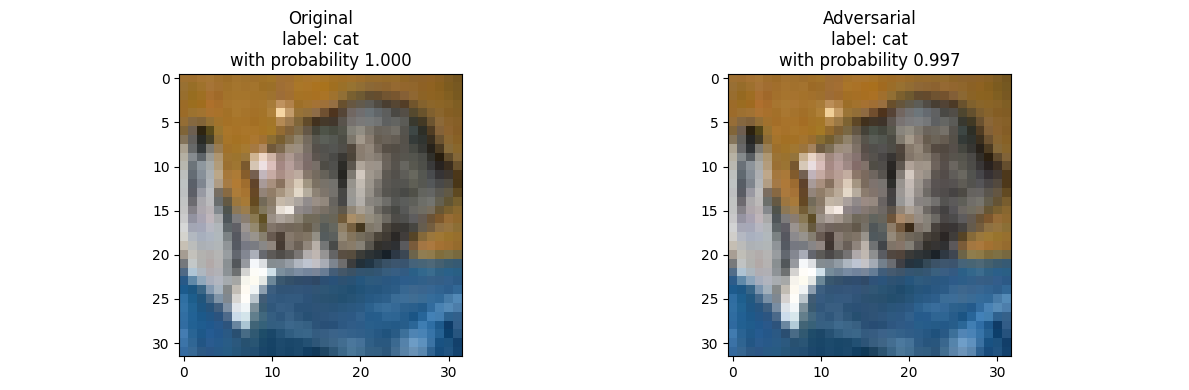

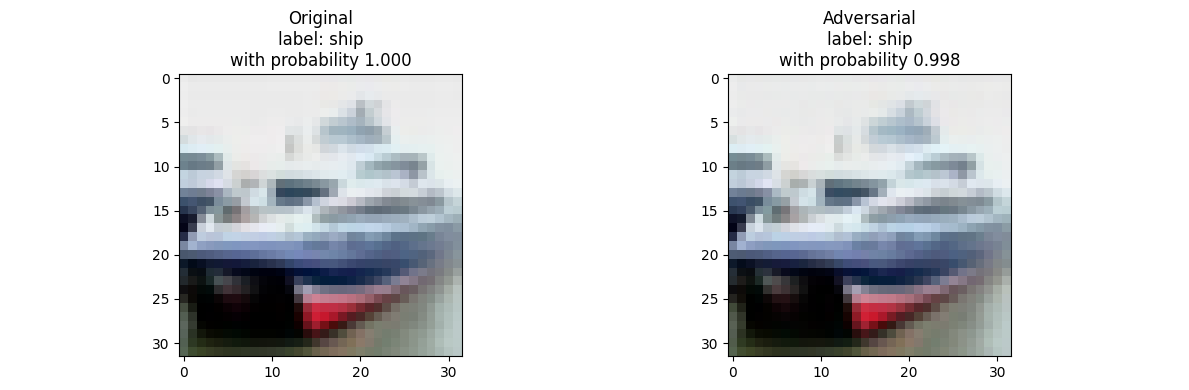

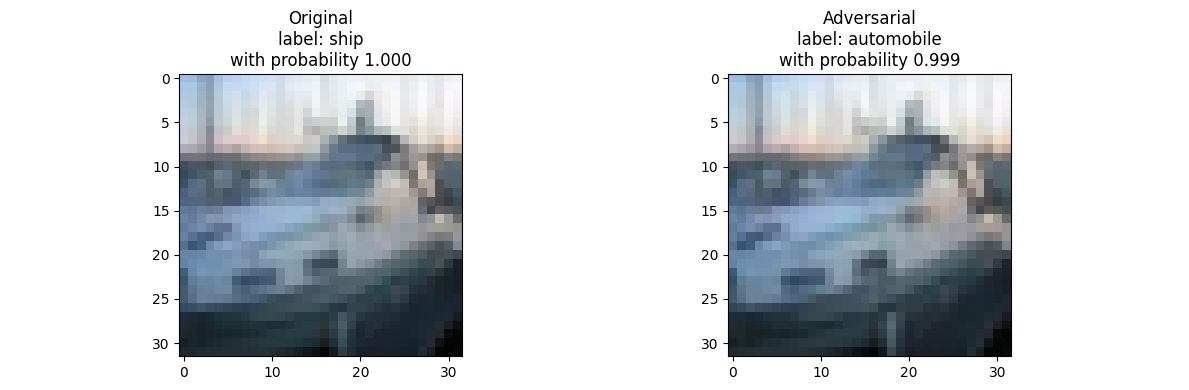

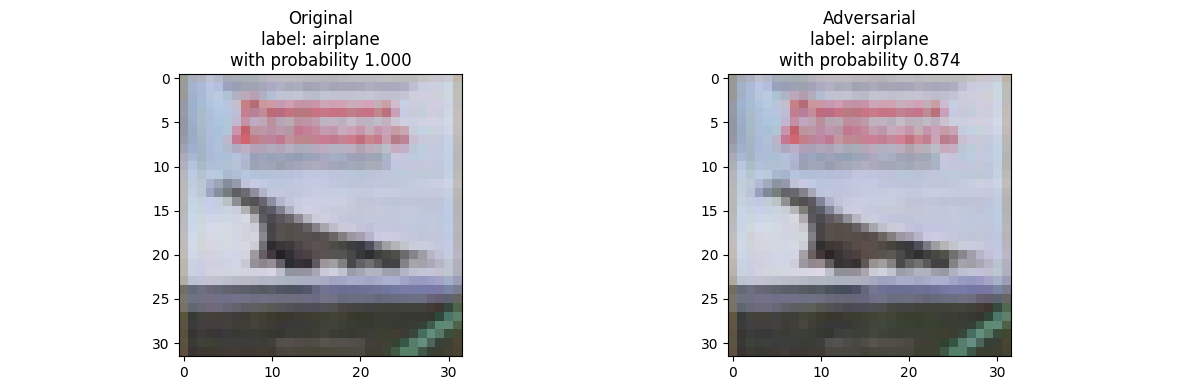

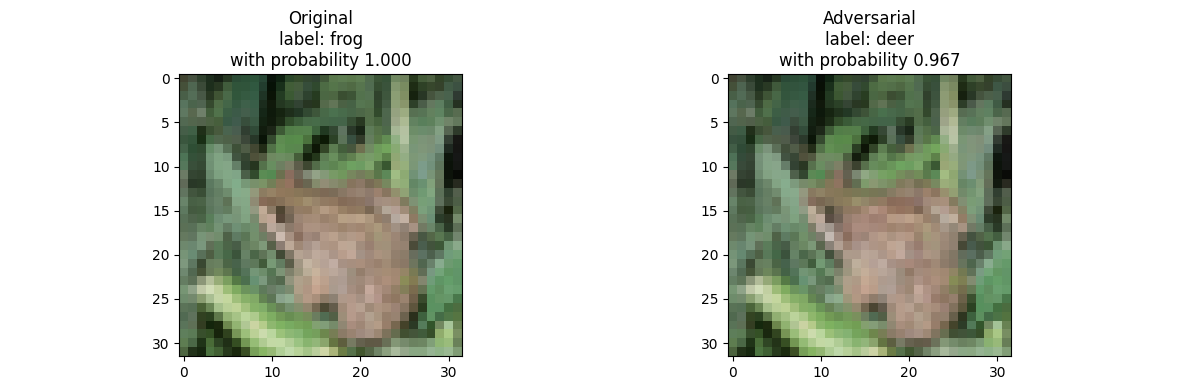

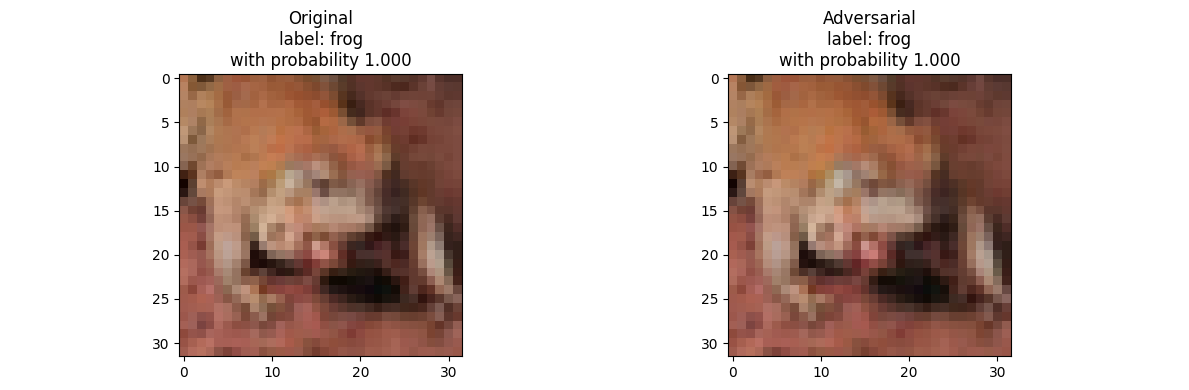

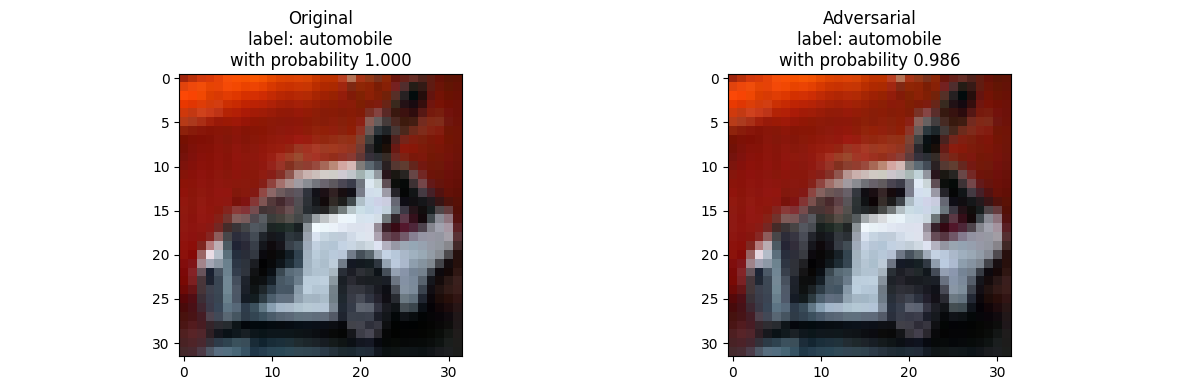

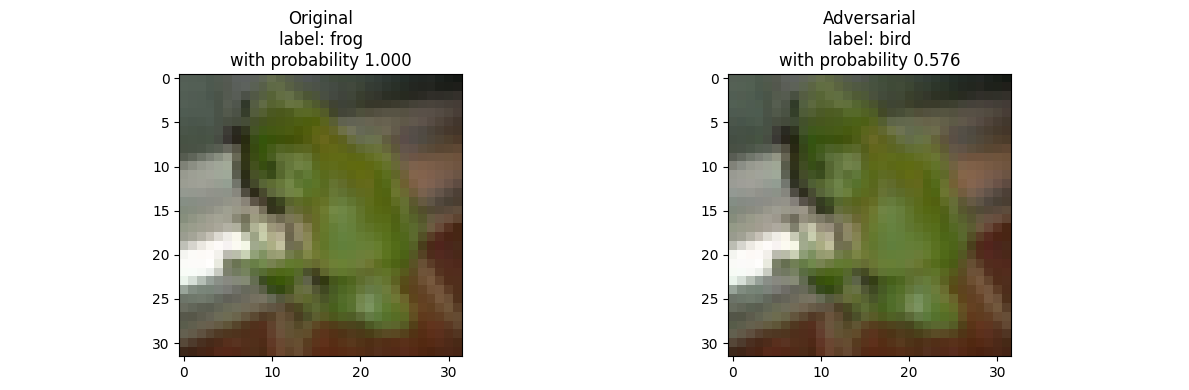

In [15]:
model = tf.keras.models.load_model(
    get_checkpoint_path("wide_resnet_adversarial_training"),
    custom_objects={
        "KaimingNormal": KaimingNormal
    }
)
model.compile(metrics=['accuracy'])
pgd_20 = PGDAttack(model, params=attack_params)
x_adv, y_adv = make_adv_test_set(test_ds, pgd_20)

clean_eval = model.evaluate(test_ds)
adv_eval = model.evaluate(x_adv, y_adv)

plots = AdversarialPlots(pgd_20, labels)
x, y = test_ds.take(1).get_single_element()
plots.generate_and_show_adversarial_batch(x, y)